# Угол между осью камеры и вертикалью

In [18]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
import math

A = np.array([[1.41280777e+03, 0.00000000e+00, 9.64533893e+02],
             [0.00000000e+00, 1.41277456e+03, 4.75848946e+02],
             [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])
dist = np.array([.03292813, -0.18150873, -0.00288867, -0.00161962,  0.15327752])

objp = np.zeros((9 * 6, 3), np.float32)
objp[:, :2] = np.mgrid[0:6, 0:9].T.reshape(-1, 2) * 0.024

# Arrays to store objects points and image from all images
objpoints = [] #coordinates in 3d in real world
imgpoints = [] #coordinates in 2d in image plane

filename = 0

cam = cv2.VideoCapture(1, cv2.CAP_DSHOW)
cam.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)
cam.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)

while(True):
    success, frame = cam.read()
    
    if (success == False):
        
        cam.release()
        cam = cv2.VideoCapture(cv2.CAP_DSHOW)
        cam.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)
        cam.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)
        continue
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    ret, corners = cv2.findChessboardCorners(gray, (6, 9), None)
    
    if (ret == True):
        s, rvec, tvec = cv2.solvePnP(objp, corners, A, dist, flags=0)
        
        if (s == False):
            continue
        
        srvec = 'rvec:' + str(rvec[0][0])[:5] + " " + str(rvec[1][0])[:5] + " " + str(rvec[2][0])[:5] + " "
        image = cv2.putText(frame, srvec, (50, 50), cv2.FONT_HERSHEY_PLAIN, 2, (0, 0, 255), 2, cv2.LINE_AA)
        
        stvec = 'tvec:' + str(tvec[0][0])[:5] + " " + str(tvec[1][0])[:5] + " " + str(tvec[2][0])[:5] + " "
        image = cv2.putText(frame, stvec, (50, 100), cv2.FONT_HERSHEY_PLAIN, 2, (0, 0, 255), 2, cv2.LINE_AA)
    
    #Сonverting vectors to board rotation angles
        Rt = cv2.Rodrigues(rvec)
        Rt = np.transpose(Rt[0])
        sy = math.sqrt(Rt[0, 0] * Rt[0, 0] + Rt[1, 0] * Rt[1, 0])
        singular = sy < 1e-6

        # rotation matrix to Euler Angles
        if not singular:
            x = math.atan2(Rt[2,1] , Rt[2,2])* (180 / np.pi)
            y = math.atan2(-Rt[2,0], sy)* (180 / np.pi)
            z = math.atan2(Rt[1,0], Rt[0,0])* (180 / np.pi)

        else:
            x = math.atan2(-Rt[1,2], Rt[1,1])* (180 / np.pi)
            y = math.atan2(-Rt[2,0], sy)* (180 / np.pi)
            z = 0

        image = cv2.putText(frame, str(x)[:5] + " " +
                                   str(y)[:5] + " " +
                                   str(z)[:5], (50, 150), cv2.FONT_HERSHEY_PLAIN, 2, (0, 0, 255), 2, cv2.LINE_AA)
    
    cv2.namedWindow('custom window', cv2.WINDOW_KEEPRATIO)
    cv2.imshow('custom window', frame)
    cv2.resizeWindow('custom window', 1280, 720)
    
    
    key = cv2.waitKey(120) & 0xFF
    
    if (key == ord('q')):
        break

cam.release()
cv2.destroyAllWindows()
cv2.waitKey(10)

-1

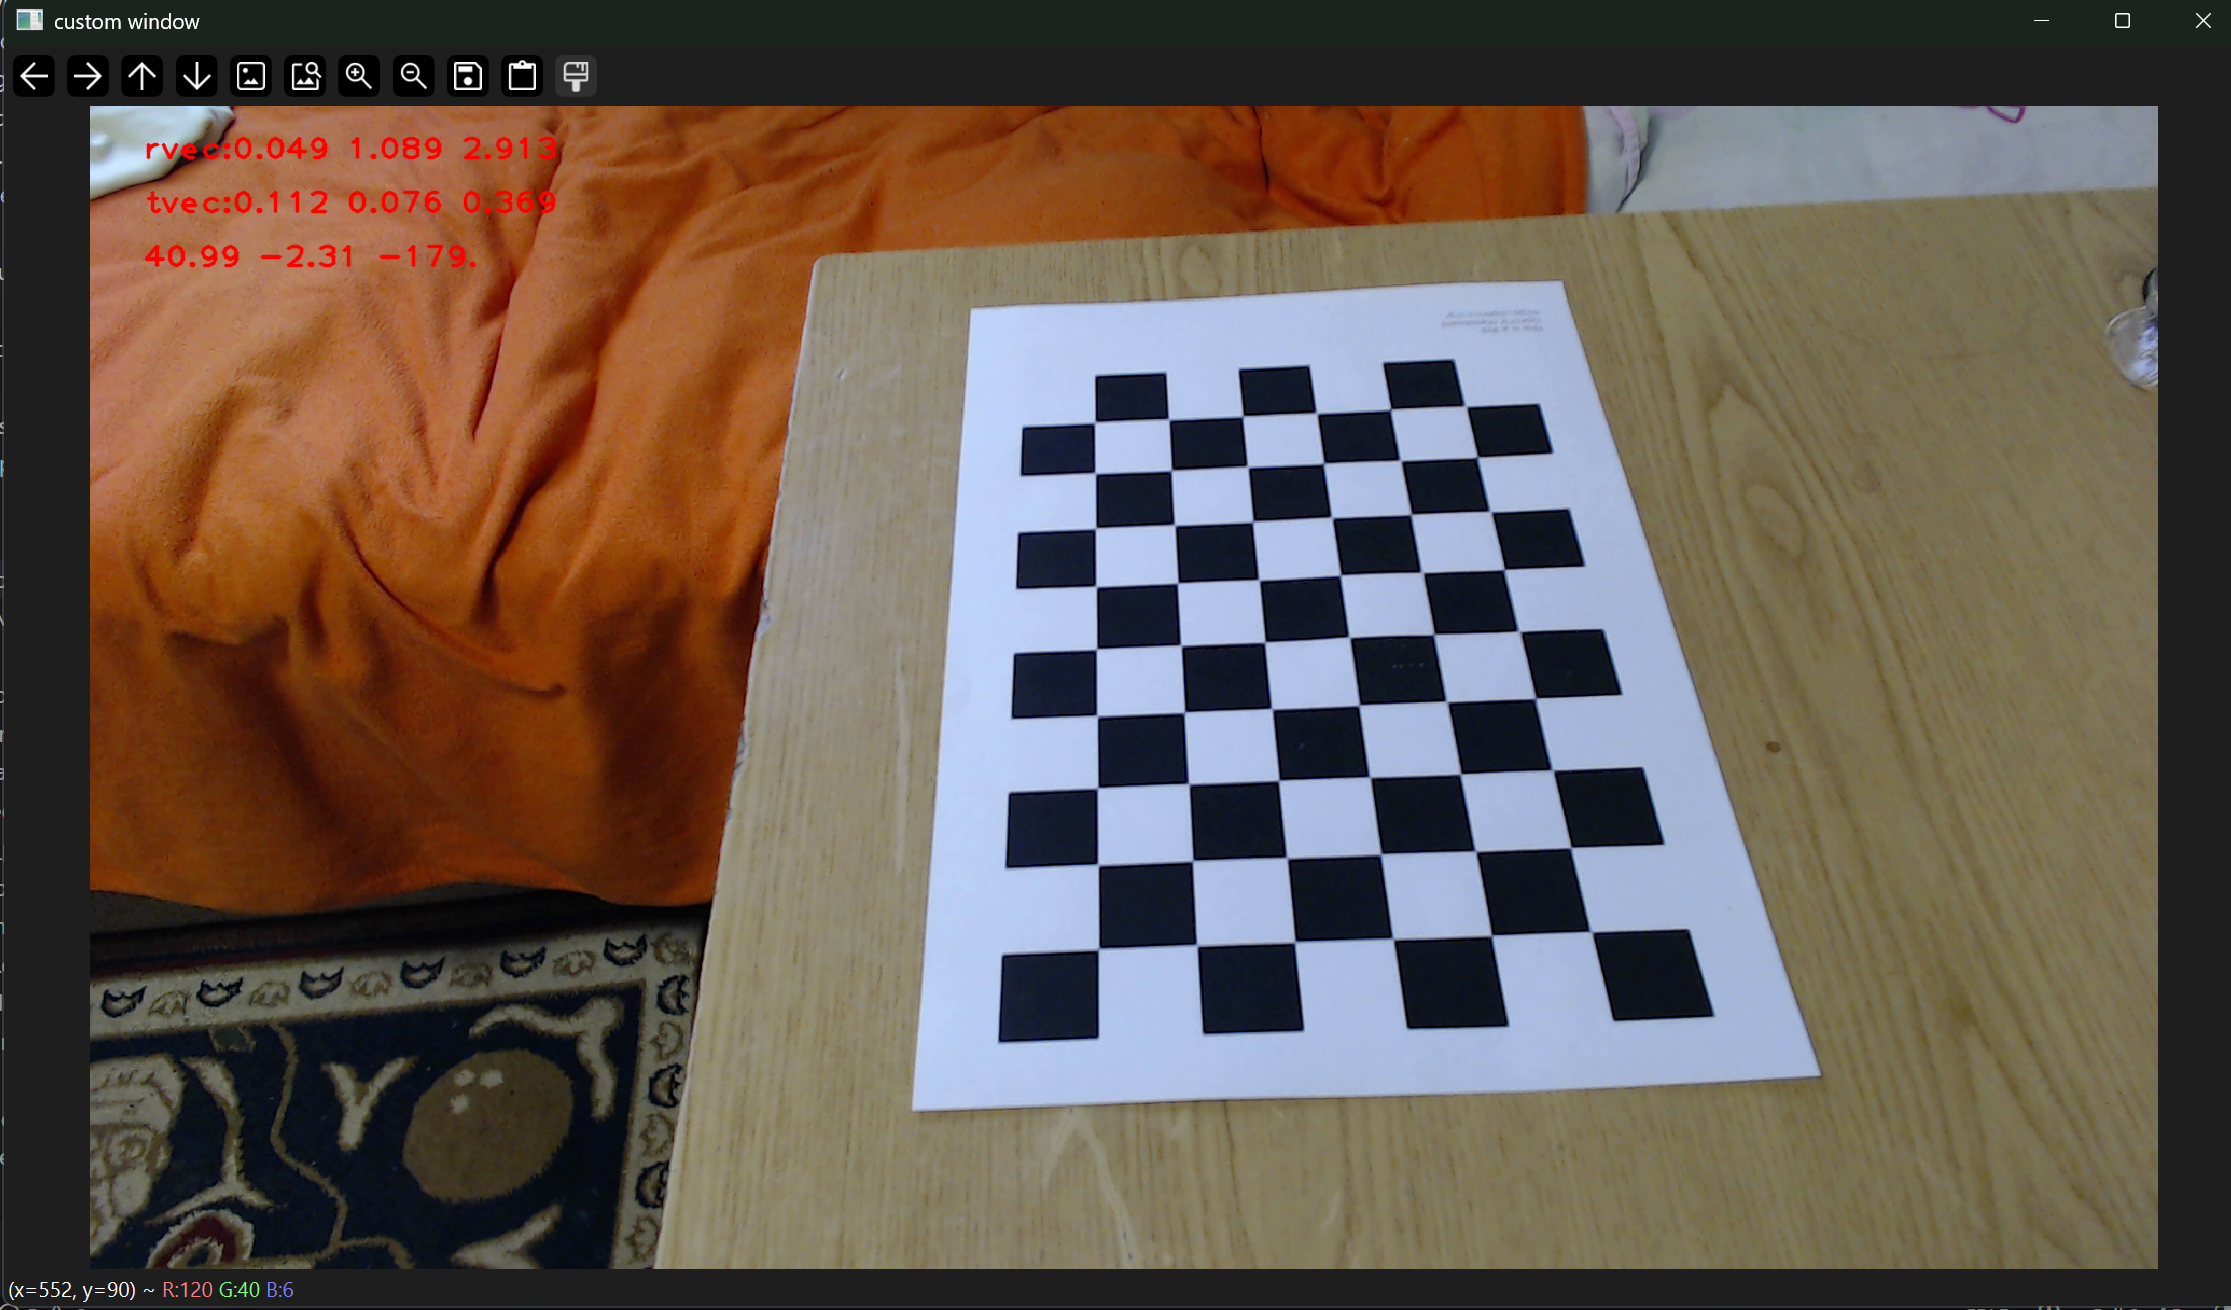

In [38]:
import numpy as np
import math
import cv2

def pic2r(A, alpha, beta, x, y, h):
    fx = A[0, 0]
    fy = A[1, 1]
    cx = A[0, 2]
    cy = A[1, 2]
    
    y_ = h / math.tan(beta + math.atan((y - cy) / fy))
    x_ = (y_**2 + h**2)**0.5 * (x - cx) / fx
    
    R = np.array([[math.cos(alpha), -math.sin(alpha)],
                  [math.sin(alpha), math.cos(alpha)]])
    
    rotated = R @ np.array([x_, y_])
    
    return rotated[0], rotated[1]

def r2pic(A, alpha, beta, xr, yr, h):
    fx = A[0, 0]
    fy = A[1, 1]
    cx = A[0, 2]
    cy = A[1, 2]
    
    # Обратное вращение
    R = np.array([[math.cos(alpha), math.sin(alpha)],
                  [-math.sin(alpha), math.cos(alpha)]])
    
    unrotated = R @ np.array([xr, yr])
    x_, y_ = unrotated[0], unrotated[1]
    
    # Обратная проекция
    y_pixel = fy * math.tan(math.atan(h / y_) - beta) + cy
    x_pixel = fx * x_ / (y_**2 + h**2)**0.5 + cx
    
    return int(x_pixel), int(y_pixel)

A = np.array([[1.41280777e+03, 0.00000000e+00, 9.64533893e+02],
             [0.00000000e+00, 1.41277456e+03, 4.75848946e+02],
             [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])

cam = cv2.VideoCapture(1, cv2.CAP_DSHOW)
cam.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)
cam.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)

while True:
    success, frame = cam.read()
    if not success:
        print("Cannot read frame. Exiting")
        break
    
    blurred = cv2.blur(frame, (7, 7))
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
    
    mask_red = cv2.inRange(hsv, (135, 90, 46), (217, 255, 255))
    mask_green = cv2.inRange(hsv, (79, 93, 115), (107, 255, 255))
    mask = cv2.bitwise_or(mask_red, mask_green)
    
    cv2.imshow("mask", mask)
    
    connectivity = 4
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity, cv2.CV_32S)
    
    coords = []
    real_coords = []
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        t = stats[i, cv2.CC_STAT_TOP]
        l = stats[i, cv2.CC_STAT_LEFT]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h_ = stats[i, cv2.CC_STAT_HEIGHT]
        
        if area >= 2000:
            x, y = (l + w // 2, t + h_)
            cv2.rectangle(frame, (l, t), (l + w, t + h_), (123, 223, 134), 3)
            cv2.circle(frame, (x, y), 5, (0, 0, 255), -1)
            coords.append((x, y))
            
            # pic2r
            xr, yr = pic2r(A, 0, (90 - 41) / 180 * math.pi, x, y, 34.5)
            real_coords.append((xr, yr))
    
    if len(real_coords) >= 2:
        x1, y1 = real_coords[0]
        x2, y2 = real_coords[1]
        
        new_x = x1 +  abs(x2 - x1)
        new_y = y1 + abs(y2 - y1)
        
        #r2pic
        new_px, new_py = r2pic(A, 0, (90 - 41) / 180 * math.pi, new_x, new_y, 34.5)
        
        cv2.circle(frame, (new_px, new_py), 8, (0, 255, 255), -1)
        
        cv2.putText(frame, f"New point: {new_x:.2f}, {new_y:.2f}", 
                   (50, 50 + len(real_coords) * 30), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2, cv2.LINE_AA)
    
    for i, ((x, y), (xr, yr)) in enumerate(zip(coords, real_coords)):
        text = f"Obj {i+1}: {xr:.2f}, {yr:.2f}"
        cv2.putText(frame, text, (50, 50 + i * 30), cv2.FONT_HERSHEY_SIMPLEX, 
                    1, (0, 255, 0), 2, cv2.LINE_AA)
    
    cv2.namedWindow('custom window', cv2.WINDOW_KEEPRATIO)
    cv2.imshow('custom window', frame)
    cv2.resizeWindow('custom window', 1280, 720)
    
    key = cv2.waitKey(90) & 0xFF
    if key == ord('q'):
        break

cam.release()
cv2.destroyAllWindows()
cv2.waitKey(10)

-1

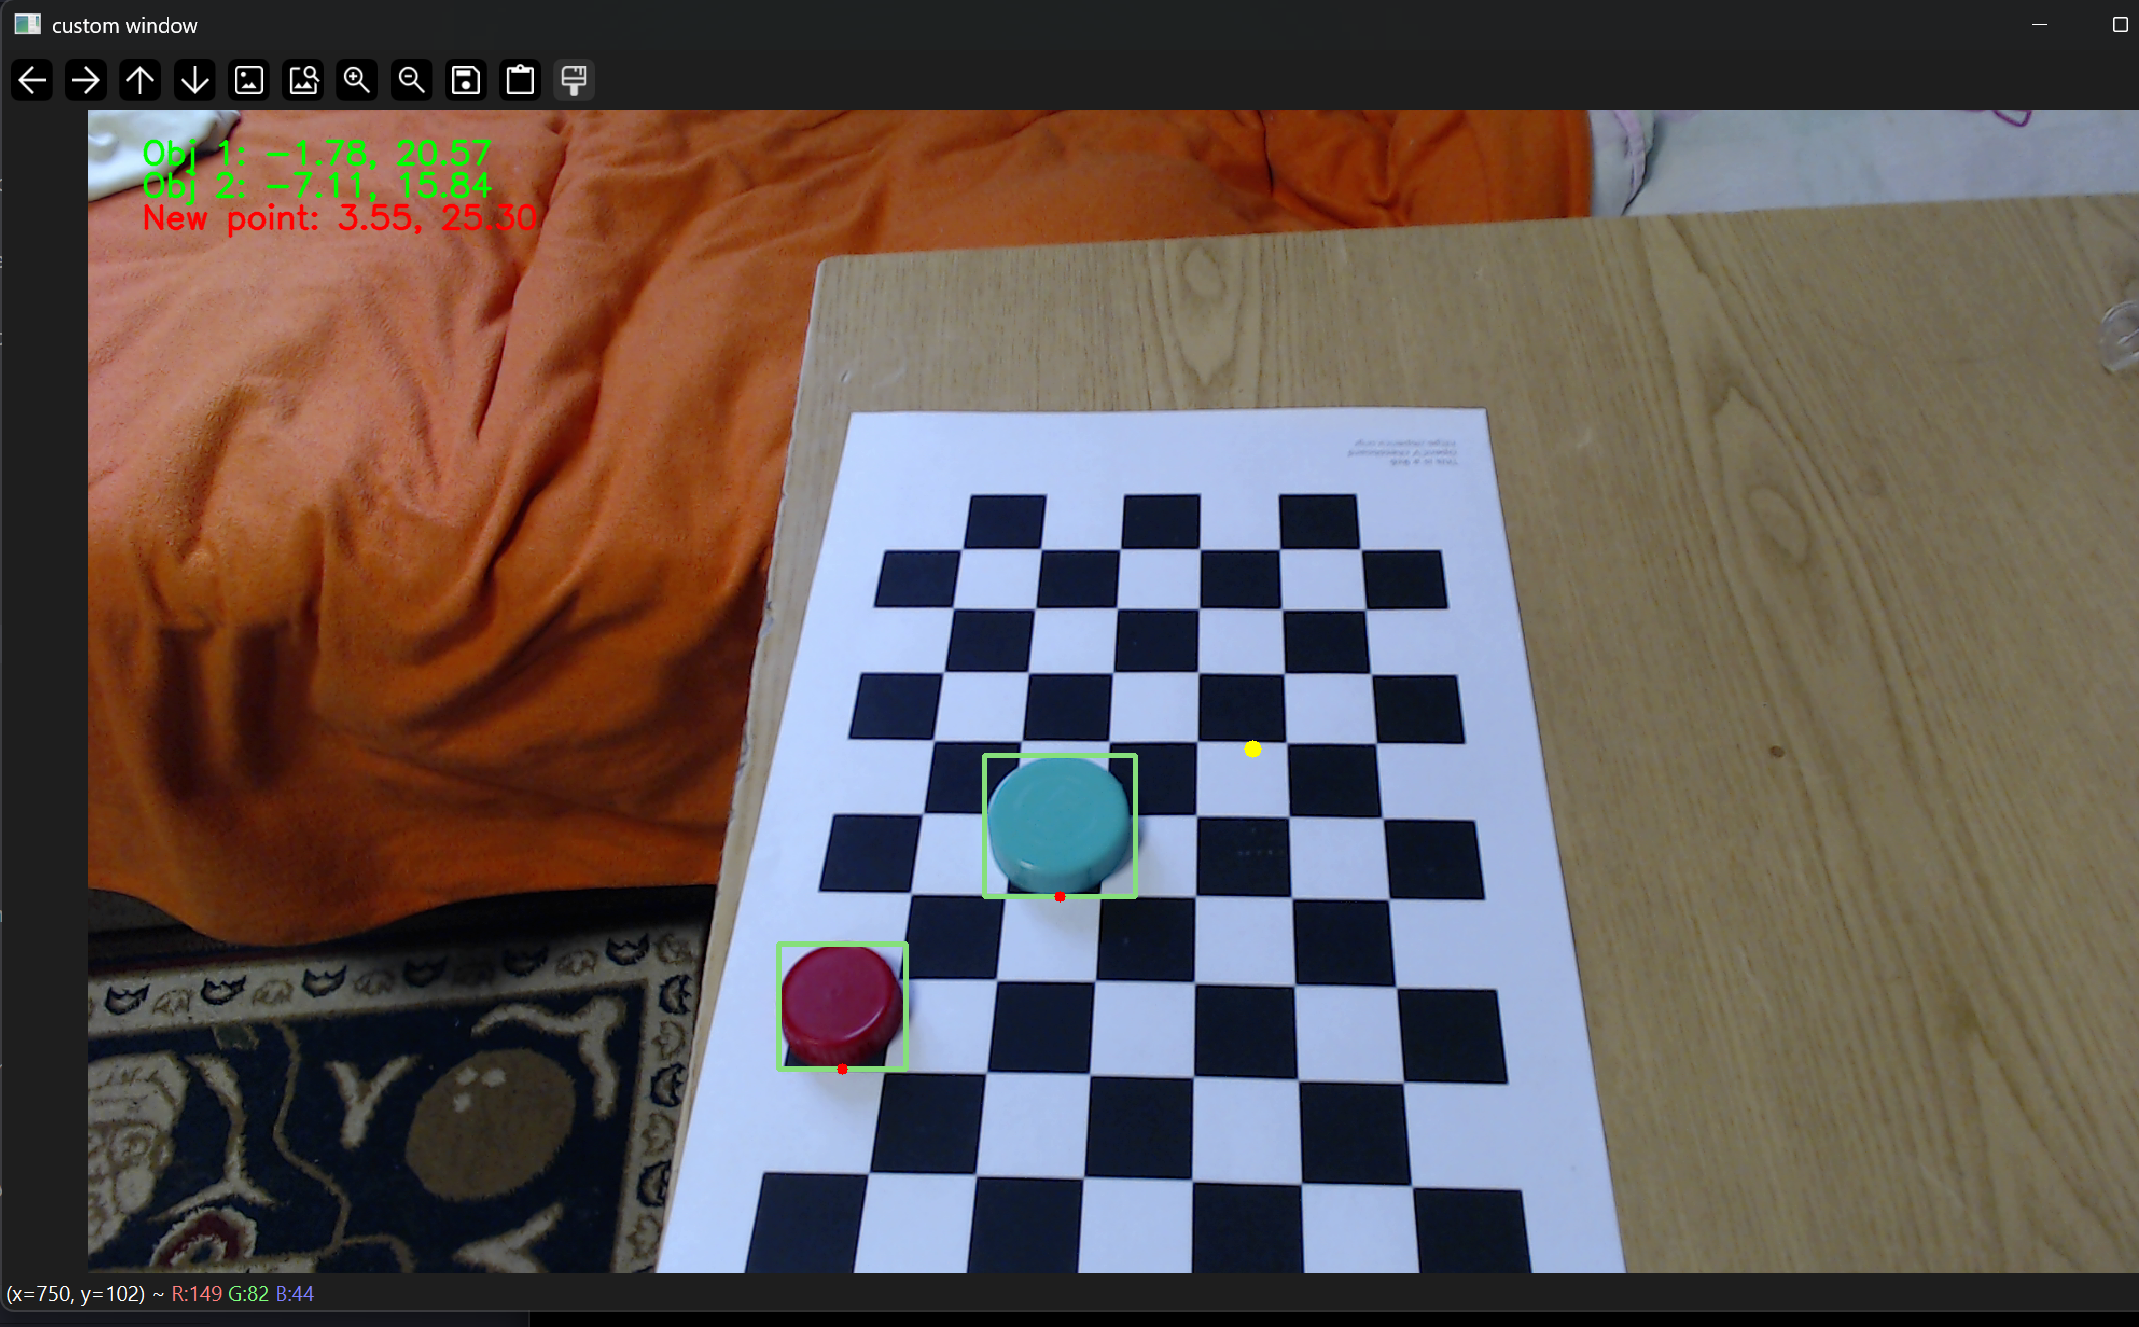